# InsightFlow — Exploratory Data Analysis

This notebook explores the cleaned Online Retail II transactional dataset to identify patterns in revenue, products, customers, countries, and sales over time.

## Objectives

- Calculate key business metrics
- Analyze revenue trends over time
- Evaluate product performance
- Explore geographic sales patterns
- Analyze customer purchasing behavior
- Examine transaction distributions and potential outliers
- Generate business-oriented insights from the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

TRANSACTIONS_PATH = (
    PROCESSED_DATA_PATH
    / "transactions_clean.csv"
)

CUSTOMERS_PATH = (
    PROCESSED_DATA_PATH
    / "customer_transactions.csv"
)

In [3]:
print(TRANSACTIONS_PATH.exists())
print(CUSTOMERS_PATH.exists())

True
True


In [4]:
transactions = pd.read_csv(
    TRANSACTIONS_PATH,
    parse_dates=["invoice_date"]
)

customer_transactions = pd.read_csv(
    CUSTOMERS_PATH,
    parse_dates=["invoice_date"]
)

C:\Users\esmak\AppData\Local\Temp\ipykernel_20364\235570850.py:1: DtypeWarning: Columns (0: invoice) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv(


In [5]:
print("Transactions:", transactions.shape)
print("Customer transactions:", customer_transactions.shape)

Transactions: (1007913, 14)
Customer transactions: (779425, 14)


In [6]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 1007913 entries, 0 to 1007912
Data columns (total 14 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   invoice       1007913 non-null  object        
 1   stock_code    1007913 non-null  str           
 2   description   1007913 non-null  str           
 3   quantity      1007913 non-null  int64         
 4   invoice_date  1007913 non-null  datetime64[us]
 5   unit_price    1007913 non-null  float64       
 6   customer_id   779425 non-null   float64       
 7   country       1007913 non-null  str           
 8   revenue       1007913 non-null  float64       
 9   year          1007913 non-null  int64         
 10  month         1007913 non-null  int64         
 11  day           1007913 non-null  int64         
 12  hour          1007913 non-null  int64         
 13  year_month    1007913 non-null  str           
dtypes: datetime64[us](1), float64(3), int64(5), object(1), str(4)

## 1. Dataset Overview

In [7]:
transactions.head()

,invoice,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue,year,month,day,hour,year_month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,7,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,7,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,7,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1,7,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1,7,2009-12


In [8]:
transactions.describe()

,quantity,invoice_date,unit_price,customer_id,revenue,year,month,day,hour
count,1.007913e+06,1007913,1.007913e+06,779425.000000,1.007913e+06,1.007913e+06,1.007913e+06,1.007913e+06,1.007913e+06
mean,1.111718e+01,2011-01-04 10:34:18.759595,4.074252e+00,15320.360461,2.031550e+01,2.010437e+03,7.403545e+00,1.535218e+01,1.302004e+01
min,1.000000e+00,2009-12-01 07:45:00,1.000000e-03,12346.000000,1.000000e-03,2.009000e+03,1.000000e+00,1.000000e+00,6.000000e+00
25%,1.000000e+00,2010-07-06 11:21:00,1.250000e+00,13971.000000,4.130000e+00,2.010000e+03,4.000000e+00,8.000000e+00,1.100000e+01
50%,4.000000e+00,2010-12-09 15:29:00,2.100000e+00,15247.000000,1.008000e+01,2.010000e+03,8.000000e+00,1.500000e+01,1.300000e+01
75%,1.200000e+01,2011-07-28 12:29:00,4.130000e+00,16794.000000,1.770000e+01,2.011000e+03,1.100000e+01,2.300000e+01,1.500000e+01
max,8.099500e+04,2011-12-09 12:50:00,2.511109e+04,18287.000000,1.684696e+05,2.011000e+03,1.200000e+01,3.100000e+01,2.000000e+01
std,1.284700e+02,NaN,5.043045e+01,1695.692775,2.057158e+02,5.764132e-01,3.499747e+00,8.639718e+00,2.433195e+00


In [9]:
transactions[
    [
        "quantity",
        "unit_price",
        "revenue"
    ]
].describe()

,quantity,unit_price,revenue
count,1.007913e+06,1.007913e+06,1.007913e+06
mean,1.111718e+01,4.074252e+00,2.031550e+01
std,1.284700e+02,5.043045e+01,2.057158e+02
min,1.000000e+00,1.000000e-03,1.000000e-03
25%,1.000000e+00,1.250000e+00,4.130000e+00
50%,4.000000e+00,2.100000e+00,1.008000e+01
75%,1.200000e+01,4.130000e+00,1.770000e+01
max,8.099500e+04,2.511109e+04,1.684696e+05


## 2. Business KPI Overview

In [10]:
total_revenue = transactions["revenue"].sum()

total_revenue

np.float64(20476260.448)

In [11]:
print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £20,476,260.45


In [12]:
total_orders = transactions["invoice"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 40,079


In [13]:
total_units = transactions["quantity"].sum()

print(f"Units Sold: {total_units:,}")

Units Sold: 11,205,148


In [14]:
unique_products = transactions["stock_code"].nunique()

print(f"Unique Products: {unique_products:,}")

Unique Products: 4,917


In [15]:
unique_countries = transactions["country"].nunique()

print(f"Countries: {unique_countries}")

Countries: 43


In [16]:
unique_customers = (
    customer_transactions["customer_id"]
    .nunique()
)

print(f"Identified Customers: {unique_customers:,}")

Identified Customers: 5,878


In [17]:
order_revenue = (
    transactions
    .groupby("invoice")["revenue"]
    .sum()
)

In [18]:
average_order_value = order_revenue.mean()

print(
    f"Average Order Value: "
    f"£{average_order_value:,.2f}"
)

Average Order Value: £510.90


In [19]:
aov_check = total_revenue / total_orders

print(average_order_value)
print(aov_check)

510.8974886598967
510.8974886598967


In [20]:
kpi_summary = pd.Series({
    "Total Revenue": total_revenue,
    "Total Orders": total_orders,
    "Units Sold": total_units,
    "Unique Products": unique_products,
    "Countries": unique_countries,
    "Identified Customers": unique_customers,
    "Average Order Value": average_order_value
})

kpi_summary

Total Revenue           2.047626e+07
Total Orders            4.007900e+04
Units Sold              1.120515e+07
Unique Products         4.917000e+03
Countries               4.300000e+01
Identified Customers    5.878000e+03
Average Order Value     5.108975e+02
dtype: float64

In [21]:
start_date = transactions["invoice_date"].min()
end_date = transactions["invoice_date"].max()

print("Start:", start_date)
print("End:", end_date)

Start: 2009-12-01 07:45:00
End: 2011-12-09 12:50:00


In [22]:
print(
    "Period:",
    end_date - start_date
)

Period: 738 days 05:05:00


## 3. Revenue Over Time

In [23]:
monthly_revenue = (
    transactions
    .groupby("year_month")["revenue"]
    .sum()
)

monthly_revenue

year_month
2009-12     822483.950
2010-01     651155.112
2010-02     551504.726
2010-03     830915.261
2010-04     678875.252
2010-05     657705.500
2010-06     749537.310
2010-07     648810.270
2010-08     695251.910
2010-09     921696.991
2010-10    1161902.220
2010-11    1464293.142
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637808.330
Name: revenue, dtype: float64

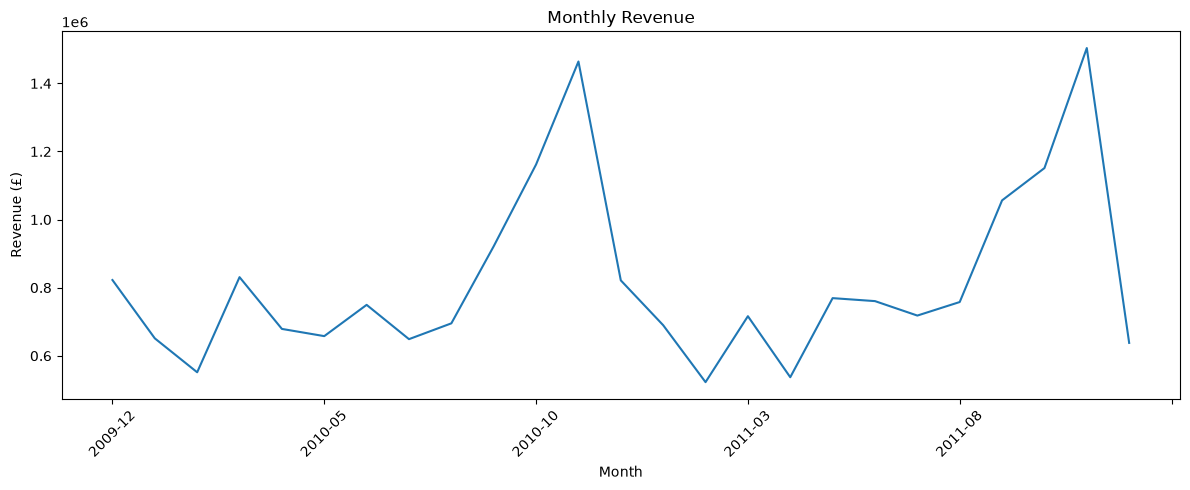

In [24]:
plt.figure(figsize=(12, 5))

monthly_revenue.plot()

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Initial Time-Series Findings

- Revenue increases substantially during October and November in both observed years.
- A similar year-end increase appears in both 2010 and 2011, suggesting a potential seasonal pattern.
- However, more complete yearly observations would be required to establish a recurring post-November decline.
- December 2011 should not be directly compared with full months because the dataset ends on December 9, 2011.
- The strong year-end performance suggests that product-level demand, inventory requirements, marketing activity, and operational capacity during this period should be investigated further.

## 4. Product Performance Analysis

This section evaluates product performance using sales volume, revenue, and order frequency.

The objective is to distinguish between:
- high-volume products,
- high-revenue products,
- and products purchased across many different orders.

In [25]:
product_summary = (
    transactions
    .groupby(["stock_code", "description"])
    .agg(
        units_sold=("quantity", "sum"),
        total_revenue=("revenue", "sum"),
        order_count=("invoice", "nunique"),
        average_unit_price=("unit_price", "mean")
    )
    .reset_index()
)

product_summary.head()

,stock_code,description,units_sold,total_revenue,order_count,average_unit_price
0,10002,INFLATABLE POLITICAL GLOBE,8671,6942.26,362,0.979155
1,10002R,ROBOT PENCIL SHARPNER,4,20.57,3,5.133333
2,10080,GROOVY CACTUS INFLATABLE,315,129.29,27,0.505000
3,10109,BENDY COLOUR PENCILS,4,1.68,1,0.420000
4,10120,DOGGY RUBBER,664,142.74,73,0.240137


In [26]:
top_products_by_units = (
    product_summary
    .sort_values(
        "units_sold",
        ascending=False
    )
    .head(10)
)

top_products_by_units[
    [
        "description",
        "units_sold",
        "total_revenue",
        "order_count"
    ]
]

,description,units_sold,total_revenue,order_count
4171,WORLD WAR 2 GLIDERS ASSTD DESIGNS,106139,24445.61,1019
4999,WHITE HANGING HEART T-LIGHT HOLDER,94142,257546.20,5356
3355,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
4640,ASSORTED COLOUR BIRD ORNAMENT,80082,129324.49,2807
2810,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247
4967,JUMBO BAG RED RETROSPOT,77280,145961.83,3245
121,BROCADE RING PURSE,70369,14766.42,456
1384,PACK OF 60 PINK PAISLEY CAKE CASES,56061,28081.73,1993
4801,60 TEATIME FAIRY CAKE CASES,54028,27041.21,2127
1607,SMALL POPCORN HOLDER,48561,42699.89,1407


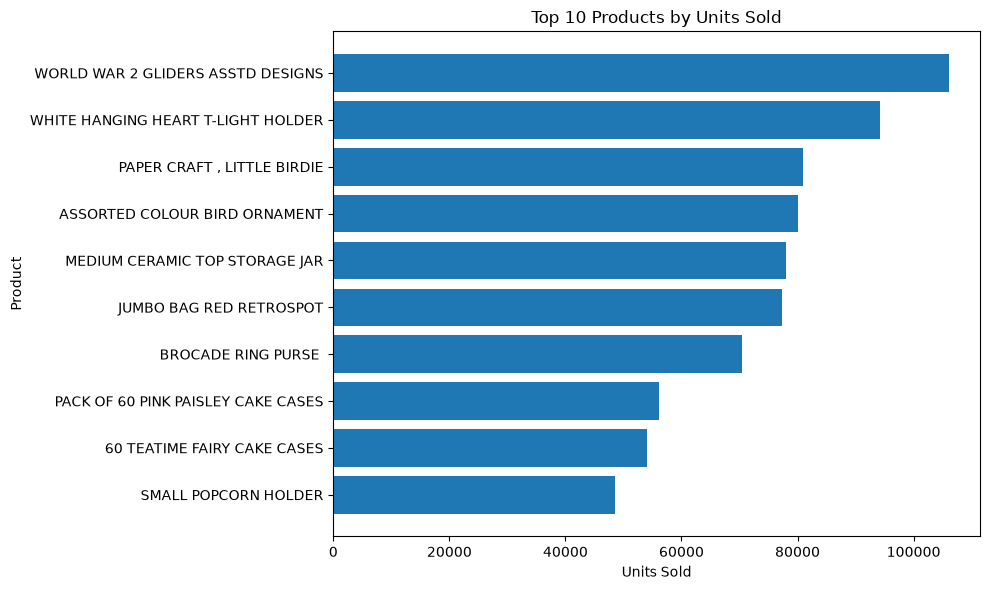

In [27]:
top_units_plot = (
    top_products_by_units
    .sort_values("units_sold")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_units_plot["description"],
    top_units_plot["units_sold"]
)

plt.title("Top 10 Products by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [28]:
top_products_by_revenue = (
    product_summary
    .sort_values(
        "total_revenue",
        ascending=False
    )
    .head(10)
)

top_products_by_revenue[
    [
        "description",
        "total_revenue",
        "units_sold",
        "order_count",
        "average_unit_price"
    ]
]

,description,total_revenue,units_sold,order_count,average_unit_price
5615,Manual,339226.24,9629,784,394.318014
1891,REGENCY CAKESTAND 3 TIER,330590.32,26478,3918,14.190418
5614,DOTCOM POSTAGE,309854.11,1415,1415,218.978170
4999,WHITE HANGING HEART T-LIGHT HOLDER,257546.20,94142,5356,3.075422
3355,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,2.080000
3716,PARTY BUNTING,148318.28,28200,2674,5.718177
4967,JUMBO BAG RED RETROSPOT,145961.83,77280,3245,2.365692
4640,ASSORTED COLOUR BIRD ORNAMENT,129324.49,80082,2807,1.859034
5617,POSTAGE,125682.42,5363,1851,29.466515
1477,PAPER CHAIN KIT 50'S CHRISTMAS,117760.29,35084,2018,3.369927


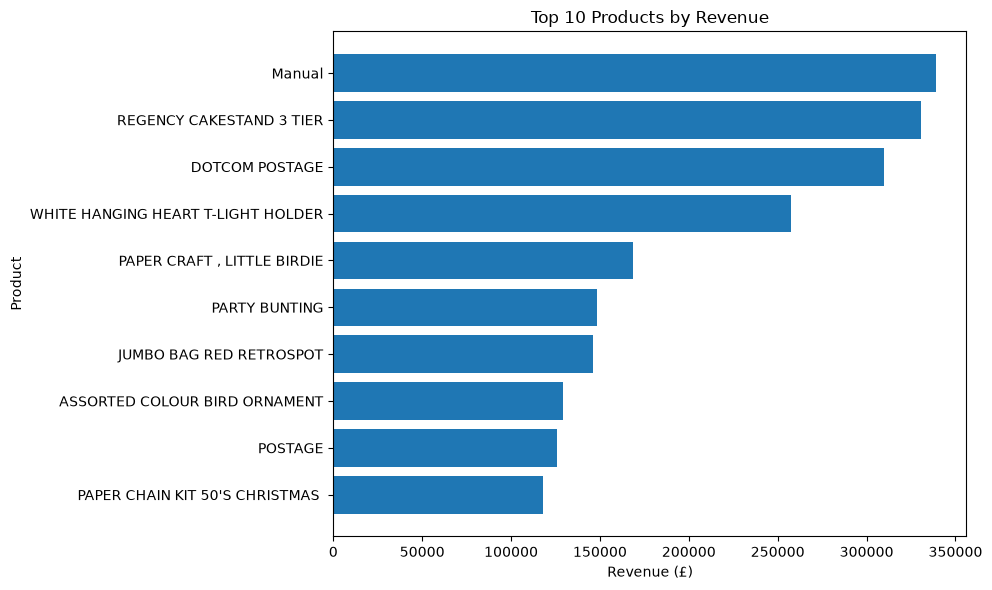

In [29]:
top_revenue_plot = (
    top_products_by_revenue
    .sort_values("total_revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_revenue_plot["description"],
    top_revenue_plot["total_revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [30]:
top_products_by_orders = (
    product_summary
    .sort_values(
        "order_count",
        ascending=False
    )
    .head(10)
)

top_products_by_orders[
    [
        "description",
        "order_count",
        "units_sold",
        "total_revenue"
    ]
]

,description,order_count,units_sold,total_revenue
4999,WHITE HANGING HEART T-LIGHT HOLDER,5356,94142,257546.20
1891,REGENCY CAKESTAND 3 TIER,3918,26478,330590.32
4967,JUMBO BAG RED RETROSPOT,3245,77280,145961.83
4640,ASSORTED COLOUR BIRD ORNAMENT,2807,80082,129324.49
3716,PARTY BUNTING,2674,28200,148318.28
289,LUNCH BAG BLACK SKULL.,2351,26678,45655.27
1357,JUMBO STORAGE BAG SUKI,2329,29182,61537.55
693,STRAWBERRY CERAMIC TRINKET BOX,2310,36628,47169.35
1875,JUMBO SHOPPER VINTAGE RED PAISLEY,2192,27281,57318.71
1948,HEART OF WICKER SMALL,2151,27908,48935.11


In [31]:
product_summary["units_per_order"] = (
    product_summary["units_sold"]
    / product_summary["order_count"]
)

In [32]:
product_summary[
    [
        "description",
        "units_sold",
        "order_count",
        "units_per_order"
    ]
].sort_values(
    "units_per_order",
    ascending=False
).head(10)

,description,units_sold,order_count,units_per_order
3355,"PAPER CRAFT , LITTLE BIRDIE",80995,1,80995.000000
5141,SMALL FAIRY CAKE FRIDGE MAGNETS,12236,5,2447.200000
49,POP-ART FLUORESCENT PENS,6193,3,2064.333333
5140,S/5 MINI ICE CREAM FRIDGE MAGNETS,1992,2,996.000000
3542,BLACK AND WHITE PAISLEY FLOWER MUG,25707,33,779.000000
3535,BIRD IN TREE MUG,4643,8,580.375000
4516,LARGE HANGING GLASS+ZINC LANTERN,560,1,560.000000
4981,BLACK SILVER FLOWER T-LIGHT HOLDER,11520,23,500.869565
3534,ORANGE FLOWER MUG,5404,11,491.272727
563,SET/6 STRAWBERRY PAPER PLATES,12846,28,458.785714


In [33]:
product_summary[
    [
        "units_sold",
        "total_revenue",
        "order_count",
        "average_unit_price",
        "units_per_order"
    ]
].describe()

,units_sold,total_revenue,order_count,average_unit_price,units_per_order
count,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000
mean,1990.257194,3636.991199,177.007105,7.860794,27.471104
std,5100.793681,11628.262121,293.818643,173.734237,1080.636966
min,1.000000,0.017000,1.000000,0.001000,1.000000
25%,77.000000,189.555000,17.000000,1.414008,2.967854
50%,471.000000,916.115000,70.000000,2.541232,6.157072
75%,1817.750000,3043.947500,211.000000,4.882353,11.380785
max,106139.000000,339226.240000,5356.000000,11062.060000,80995.000000


In [34]:
product_summary["revenue_share"] = (
    product_summary["total_revenue"]
    / product_summary["total_revenue"].sum()
)

In [35]:
top_revenue_share = (
    product_summary
    .sort_values(
        "revenue_share",
        ascending=False
    )
    .head(10)
)

top_revenue_share[
    [
        "description",
        "total_revenue",
        "revenue_share"
    ]
]

,description,total_revenue,revenue_share
5615,Manual,339226.24,0.016567
1891,REGENCY CAKESTAND 3 TIER,330590.32,0.016145
5614,DOTCOM POSTAGE,309854.11,0.015132
4999,WHITE HANGING HEART T-LIGHT HOLDER,257546.20,0.012578
3355,"PAPER CRAFT , LITTLE BIRDIE",168469.60,0.008228
3716,PARTY BUNTING,148318.28,0.007243
4967,JUMBO BAG RED RETROSPOT,145961.83,0.007128
4640,ASSORTED COLOUR BIRD ORNAMENT,129324.49,0.006316
5617,POSTAGE,125682.42,0.006138
1477,PAPER CHAIN KIT 50'S CHRISTMAS,117760.29,0.005751


In [36]:
top_revenue_share = top_revenue_share.copy()

top_revenue_share["revenue_share_pct"] = (
    top_revenue_share["revenue_share"] * 100
)

top_revenue_share[
    [
        "description",
        "total_revenue",
        "revenue_share_pct"
    ]
]

,description,total_revenue,revenue_share_pct
5615,Manual,339226.24,1.656681
1891,REGENCY CAKESTAND 3 TIER,330590.32,1.614505
5614,DOTCOM POSTAGE,309854.11,1.513236
4999,WHITE HANGING HEART T-LIGHT HOLDER,257546.20,1.257779
3355,"PAPER CRAFT , LITTLE BIRDIE",168469.60,0.822756
3716,PARTY BUNTING,148318.28,0.724343
4967,JUMBO BAG RED RETROSPOT,145961.83,0.712834
4640,ASSORTED COLOUR BIRD ORNAMENT,129324.49,0.631583
5617,POSTAGE,125682.42,0.613796
1477,PAPER CHAIN KIT 50'S CHRISTMAS,117760.29,0.575106


In [37]:
top_10_revenue_share = (
    product_summary
    .nlargest(10, "total_revenue")["total_revenue"]
    .sum()
    / product_summary["total_revenue"].sum()
)

print(
    f"Top 10 Product Revenue Share: "
    f"{top_10_revenue_share:.2%}"
)

Top 10 Product Revenue Share: 10.12%


### 4.1 Investigation of Non-Product Records

Some of the highest-revenue descriptions may not represent standard retail products. Before interpreting product rankings, these records are investigated separately.

In [38]:
manual_rows = transactions[
    transactions["description"].str.upper() == "MANUAL"
]

manual_rows[
    [
        "invoice",
        "stock_code",
        "description",
        "quantity",
        "unit_price",
        "customer_id",
        "country",
        "revenue"
    ]
].head(20)

,invoice,stock_code,description,quantity,unit_price,customer_id,country,revenue
2572,489609,M,Manual,1,4.00,NaN,United Kingdom,4.00
10975,490300,M,Manual,1,0.85,12970.0,United Kingdom,0.85
10976,490300,M,Manual,1,0.21,12970.0,United Kingdom,0.21
16872,490760,M,Manual,1,10.00,14295.0,United Kingdom,10.00
17305,490881,M,Manual,1,10.00,16210.0,United Kingdom,10.00
18812,490999,M,Manual,1,15.95,13883.0,United Kingdom,15.95
18813,490999,M,Manual,1,8.70,13883.0,United Kingdom,8.70
22123,491176,M,Manual,1,1213.02,13091.0,United Kingdom,1213.02
36445,492484,M,Manual,4,0.35,15862.0,United Kingdom,1.40
37190,492586,M,Manual,1,1.25,NaN,United Kingdom,1.25


In [39]:
manual_rows[
    [
        "quantity",
        "unit_price",
        "revenue"
    ]
].describe()

,quantity,unit_price,revenue
count,851.000000,851.000000,851.000000
mean,11.320799,392.018907,398.638414
std,81.876215,1448.974120,1447.813530
min,1.000000,0.060000,0.080000
25%,1.000000,0.850000,2.550000
50%,1.000000,2.950000,8.850000
75%,3.000000,155.715000,187.875000
max,1600.000000,25111.090000,25111.090000


In [40]:
print("Rows:", len(manual_rows))
print("Orders:", manual_rows["invoice"].nunique())
print("Revenue:", manual_rows["revenue"].sum())
print("Unique stock codes:", manual_rows["stock_code"].nunique())

Rows: 851
Orders: 788
Revenue: 339241.29000000004
Unique stock codes: 2


In [41]:
postage_rows = transactions[
    transactions["description"].str.upper() == "DOTCOM POSTAGE"
]

postage_rows[
    [
        "invoice",
        "stock_code",
        "description",
        "quantity",
        "unit_price",
        "customer_id",
        "country",
        "revenue"
    ]
].head(20)

,invoice,stock_code,description,quantity,unit_price,customer_id,country,revenue
2255,489597,DOT,DOTCOM POSTAGE,1,647.19,NaN,United Kingdom,647.19
2415,489600,DOT,DOTCOM POSTAGE,1,55.96,NaN,United Kingdom,55.96
2427,489601,DOT,DOTCOM POSTAGE,1,68.39,NaN,United Kingdom,68.39
2447,489602,DOT,DOTCOM POSTAGE,1,59.35,NaN,United Kingdom,59.35
2495,489603,DOT,DOTCOM POSTAGE,1,42.39,NaN,United Kingdom,42.39
2520,489604,DOT,DOTCOM POSTAGE,1,50.87,NaN,United Kingdom,50.87
2561,489607,DOT,DOTCOM POSTAGE,1,76.30,NaN,United Kingdom,76.30
2573,489609,DOT,DOTCOM POSTAGE,1,74.61,NaN,United Kingdom,74.61
2640,489612,DOT,DOTCOM POSTAGE,1,87.39,NaN,United Kingdom,87.39
2675,489614,DOT,DOTCOM POSTAGE,1,80.30,NaN,United Kingdom,80.30


In [42]:
print("Rows:", len(postage_rows))
print("Orders:", postage_rows["invoice"].nunique())
print("Revenue:", postage_rows["revenue"].sum())
print("Unique stock codes:", postage_rows["stock_code"].nunique())

Rows: 1415
Orders: 1415
Revenue: 309854.11
Unique stock codes: 1


In [43]:
non_product_revenue = (
    manual_rows["revenue"].sum()
    + postage_rows["revenue"].sum()
)

non_product_share = (
    non_product_revenue
    / transactions["revenue"].sum()
)

print(f"Combined Revenue: £{non_product_revenue:,.2f}")
print(f"Share of Total Revenue: {non_product_share:.2%}")

Combined Revenue: £649,095.40
Share of Total Revenue: 3.17%


In [44]:
non_product_descriptions = [
    "MANUAL",
    "DOTCOM POSTAGE"
]

product_transactions = transactions[
    ~transactions["description"]
    .str.upper()
    .isin(non_product_descriptions)
].copy()

In [45]:
print("All transaction rows:", len(transactions))
print("Product transaction rows:", len(product_transactions))
print(
    "Excluded rows:",
    len(transactions) - len(product_transactions)
)

All transaction rows: 1007913
Product transaction rows: 1005647
Excluded rows: 2266


In [46]:
little_birdie = product_transactions[
    product_transactions["description"]
    .str.upper()
    .eq("PAPER CRAFT , LITTLE BIRDIE")
]

little_birdie[
    [
        "invoice",
        "stock_code",
        "description",
        "quantity",
        "unit_price",
        "invoice_date",
        "customer_id",
        "country",
        "revenue"
    ]
]

,invoice,stock_code,description,quantity,unit_price,invoice_date,customer_id,country,revenue
1006438,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,2011-12-09 09:15:00,16446.0,United Kingdom,168469.6


In [50]:
product_transactions[
    product_transactions["description"]
    .str.contains(
        "LITTLE BIRDIE",
        case=False,
        na=False
    )
][
    [
        "invoice",
        "stock_code",
        "description",
        "quantity",
        "unit_price",
        "invoice_date",
        "customer_id",
        "country",
        "revenue"
    ]
]

,invoice,stock_code,description,quantity,unit_price,invoice_date,customer_id,country,revenue
1006438,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,2011-12-09 09:15:00,16446.0,United Kingdom,168469.6


In [48]:
birdie_invoice = little_birdie["invoice"].iloc[0]

product_transactions[
    product_transactions["invoice"] == birdie_invoice
][
    [
        "invoice",
        "stock_code",
        "description",
        "quantity",
        "unit_price",
        "customer_id",
        "country",
        "revenue"
    ]
].sort_values("revenue", ascending=False)

,invoice,stock_code,description,quantity,unit_price,customer_id,country,revenue
1006438,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0,United Kingdom,168469.6


In [49]:
birdie_customer = little_birdie["customer_id"].iloc[0]

product_transactions[
    product_transactions["customer_id"] == birdie_customer
][
    [
        "invoice",
        "invoice_date",
        "description",
        "quantity",
        "unit_price",
        "revenue"
    ]
].sort_values("invoice_date")

,invoice,invoice_date,description,quantity,unit_price,revenue
671063,553573,2011-05-18 09:52:00,PANTRY SCRUBBING BRUSH,1,1.65,1.65
671064,553573,2011-05-18 09:52:00,PANTRY PASTRY BRUSH,1,1.25,1.25
1006438,581483,2011-12-09 09:15:00,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60


In [51]:
product_transactions["is_extreme_bulk"] = (
    product_transactions["quantity"] >= 10000
)

In [52]:
product_transactions[
    product_transactions["is_extreme_bulk"]
][
    [
        "invoice",
        "stock_code",
        "description",
        "quantity",
        "unit_price",
        "customer_id",
        "country",
        "revenue"
    ]
].sort_values("quantity", ascending=False)

,invoice,stock_code,description,quantity,unit_price,customer_id,country,revenue
1006438,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0,United Kingdom,168469.6
542683,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0,United Kingdom,77183.6
87082,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,0.10,13902.0,Denmark,1915.2
121865,501534,21091,SET/6 WOODLAND PAPER PLATES,12960,0.10,13902.0,Denmark,1296.0
121863,501534,21099,SET/6 STRAWBERRY PAPER CUPS,12960,0.10,13902.0,Denmark,1296.0
121866,501534,21085,SET/6 WOODLAND PAPER CUPS,12744,0.10,13902.0,Denmark,1274.4
121864,501534,21092,SET/6 STRAWBERRY PAPER PLATES,12480,0.10,13902.0,Denmark,1248.0
129396,502269,21982,PACK OF 12 SUKI TISSUES,10000,0.25,17940.0,United Kingdom,2500.0
129395,502269,21984,PACK OF 12 PINK PAISLEY TISSUES,10000,0.25,17940.0,United Kingdom,2500.0
129398,502269,21981,PACK OF 12 WOODLAND TISSUES,10000,0.25,17940.0,United Kingdom,2500.0


In [53]:
product_summary_clean = (
    product_transactions
    .groupby(["stock_code", "description"])
    .agg(
        total_revenue=("revenue", "sum"),
        units_sold=("quantity", "sum"),
        order_count=("invoice", "nunique"),
        average_unit_price=("unit_price", "mean")
    )
    .reset_index()
)

product_summary_clean = (
    product_summary_clean
    .sort_values("total_revenue", ascending=False)
)

product_summary_clean.head(10)

,stock_code,description,total_revenue,units_sold,order_count,average_unit_price
1891,22423,REGENCY CAKESTAND 3 TIER,330590.32,26478,3918,14.190418
4999,85123A,WHITE HANGING HEART T-LIGHT HOLDER,257546.20,94142,5356,3.075422
3355,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,2.080000
3716,47566,PARTY BUNTING,148318.28,28200,2674,5.718177
4967,85099B,JUMBO BAG RED RETROSPOT,145961.83,77280,3245,2.365692
4640,84879,ASSORTED COLOUR BIRD ORNAMENT,129324.49,80082,2807,1.859034
5615,POST,POSTAGE,125682.42,5363,1851,29.466515
1477,22086,PAPER CHAIN KIT 50'S CHRISTMAS,117760.29,35084,2018,3.369927
2810,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247,1.468480
4058,79321,CHILLI LIGHTS,80540.88,15841,1135,6.290666


In [54]:
high_revenue_low_orders = (
    product_summary_clean[
        product_summary_clean["order_count"] <= 5
    ]
    .sort_values("total_revenue", ascending=False)
    .head(20)
)

high_revenue_low_orders[
    [
        "description",
        "total_revenue",
        "units_sold",
        "order_count",
        "average_unit_price"
    ]
]

,description,total_revenue,units_sold,order_count,average_unit_price
3355,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,2.080000
1983,PICNIC BASKET WICKER 60 PIECES,39619.50,61,2,649.500000
5592,AMAZON FEE,20467.80,3,3,6822.600000
5593,Adjust bad debt,11062.06,1,1,11062.060000
5141,SMALL FAIRY CAKE FRIDGE MAGNETS,6875.00,12236,5,1.300000
2332,"MIRROR, ARCHED GEORGIAN",3884.00,200,1,19.420000
34,ENGLISH ROSE EDWARDIAN PARASOL,1567.00,509,4,10.500000
4736,BLUE KASHMIRI COFFEE TABLE,1359.95,27,4,62.487500
4735,PINK KASHMIRI COFFEE TABLE,1050.00,20,3,40.000000
2771,MISELTOE HEART WREATH CREAM,996.00,240,1,4.150000


### 4.2 Investigation of Special Stock Codes

The initial product ranking revealed several records that may represent
operational charges or accounting adjustments rather than physical products.

Examples include:
- Manual
- DOTCOM POSTAGE
- AMAZON FEE
- Adjust bad debt

Before finalizing the product-level analysis, special stock codes are
investigated to distinguish merchandise from non-product transactions.

In [55]:
special_stock_codes = (
    transactions[
        ~transactions["stock_code"]
        .astype(str)
        .str.fullmatch(r"\d+[A-Za-z]?")
    ]
    .groupby(["stock_code", "description"])
    .agg(
        row_count=("invoice", "size"),
        order_count=("invoice", "nunique"),
        total_revenue=("revenue", "sum")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

special_stock_codes.head(50)

,stock_code,description,row_count,order_count,total_revenue
31,M,Manual,846,784,339226.240
30,DOT,DOTCOM POSTAGE,1415,1415,309854.110
33,POST,POSTAGE,1851,1851,125682.420
0,15056BL,EDWARDIAN PARASOL BLACK,869,857,47267.450
8,AMAZONFEE,AMAZON FEE,3,3,20467.800
12,C2,CARRIAGE,267,267,13426.000
9,B,Adjust bad debt,1,1,11062.060
4,79323LP,LIGHT PINK CHERRY LIGHTS,170,170,8481.190
6,ADJUST,Adjustment by john on 26/01/2010 17,16,16,6563.500
3,79323GR,GREEN CHERRY LIGHTS,83,83,3209.360


In [56]:
extreme_bulk_summary = (
    product_transactions[
        product_transactions["quantity"] >= 10000
    ]
    .groupby("customer_id")
    .agg(
        transaction_rows=("invoice", "size"),
        orders=("invoice", "nunique"),
        products=("stock_code", "nunique"),
        units=("quantity", "sum"),
        revenue=("revenue", "sum")
    )
    .sort_values("units", ascending=False)
)

extreme_bulk_summary

,transaction_rows,orders,products,units,revenue
customer_id,,,,,
16446.0,1,1,1,80995,168469.6
12346.0,1,1,1,74215,77183.6
13902.0,5,2,5,70296,7029.6
17940.0,4,1,4,40000,10000.0


### 4.3 Classification of Non-Product Transactions

The investigation of special stock codes showed that unusual stock-code
formats cannot be automatically classified as non-product records.

Several legitimate merchandise items also use non-standard stock codes.
Therefore, non-product transactions are identified using explicit
business-related stock codes rather than removing all unusual codes.

Operational charges, accounting adjustments, postage, discounts, and
test records are excluded from product-performance rankings while the
underlying transaction data remains unchanged.

In [57]:
non_product_codes = [
    "M",
    "DOT",
    "POST",
    "AMAZONFEE",
    "C2",
    "B",
    "ADJUST",
    "ADJUST2",
    "BANK CHARGES",
    "D",
    "TEST001",
    "TEST002"
]

In [58]:
merchandise_transactions = transactions[
    ~transactions["stock_code"]
    .astype(str)
    .str.upper()
    .isin(non_product_codes)
].copy()

In [59]:
print("All transaction rows:", len(transactions))
print("Merchandise transaction rows:", len(merchandise_transactions))
print("Excluded rows:", len(transactions) - len(merchandise_transactions))

All transaction rows: 1007913
Merchandise transaction rows: 1003437
Excluded rows: 4476


In [60]:
merchandise_summary = (
    merchandise_transactions
    .groupby(["stock_code", "description"])
    .agg(
        total_revenue=("revenue", "sum"),
        units_sold=("quantity", "sum"),
        order_count=("invoice", "nunique"),
        average_unit_price=("unit_price", "mean")
    )
    .reset_index()
)

In [61]:
top_merchandise_by_revenue = (
    merchandise_summary
    .sort_values("total_revenue", ascending=False)
    .head(15)
)

top_merchandise_by_revenue[
    [
        "description",
        "total_revenue",
        "units_sold",
        "order_count",
        "average_unit_price"
    ]
]

,description,total_revenue,units_sold,order_count,average_unit_price
1891,REGENCY CAKESTAND 3 TIER,330590.32,26478,3918,14.190418
4999,WHITE HANGING HEART T-LIGHT HOLDER,257546.20,94142,5356,3.075422
3355,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,2.080000
3716,PARTY BUNTING,148318.28,28200,2674,5.718177
4967,JUMBO BAG RED RETROSPOT,145961.83,77280,3245,2.365692
4640,ASSORTED COLOUR BIRD ORNAMENT,129324.49,80082,2807,1.859034
1477,PAPER CHAIN KIT 50'S CHRISTMAS,117760.29,35084,2018,3.369927
2810,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247,1.468480
4058,CHILLI LIGHTS,80540.88,15841,1135,6.290666
4227,ROTATING SILVER ANGELS T-LIGHT HLDR,71300.40,31409,756,3.342535


In [62]:
top_merchandise_by_orders = (
    merchandise_summary
    .sort_values("order_count", ascending=False)
    .head(15)
)

top_merchandise_by_orders[
    [
        "description",
        "order_count",
        "units_sold",
        "total_revenue"
    ]
]

,description,order_count,units_sold,total_revenue
4999,WHITE HANGING HEART T-LIGHT HOLDER,5356,94142,257546.20
1891,REGENCY CAKESTAND 3 TIER,3918,26478,330590.32
4967,JUMBO BAG RED RETROSPOT,3245,77280,145961.83
4640,ASSORTED COLOUR BIRD ORNAMENT,2807,80082,129324.49
3716,PARTY BUNTING,2674,28200,148318.28
289,LUNCH BAG BLACK SKULL.,2351,26678,45655.27
1357,JUMBO STORAGE BAG SUKI,2329,29182,61537.55
693,STRAWBERRY CERAMIC TRINKET BOX,2310,36628,47169.35
1875,JUMBO SHOPPER VINTAGE RED PAISLEY,2192,27281,57318.71
1948,HEART OF WICKER SMALL,2151,27908,48935.11


In [63]:
top_10_merchandise_share = (
    merchandise_summary
    .nlargest(10, "total_revenue")["total_revenue"]
    .sum()
    / merchandise_summary["total_revenue"].sum()
)

print(
    f"Top 10 Merchandise Revenue Share: "
    f"{top_10_merchandise_share:.2%}"
)

Top 10 Merchandise Revenue Share: 7.80%


### 4.4 Product Performance Findings

- Product-performance analysis was separated from operational and accounting records such as postage, manual adjustments, Amazon fees, bank charges, and test transactions.
- 4,476 records were excluded from merchandise-level analysis, representing approximately 0.44% of the cleaned transaction dataset.
- REGENCY CAKESTAND 3 TIER generated the highest merchandise revenue while also appearing in a large number of orders, indicating broad and recurring demand.
- WHITE HANGING HEART T-LIGHT HOLDER appeared in the highest number of orders and was also one of the largest revenue-generating products.
- Several products, including JUMBO BAG RED RETROSPOT, ASSORTED COLOUR BIRD ORNAMENT, and PARTY BUNTING, performed strongly across both revenue and order-frequency metrics.
- PAPER CRAFT , LITTLE BIRDIE generated exceptionally high revenue from a single bulk transaction. Its revenue ranking therefore should not be interpreted as evidence of broad or recurring demand.
- Extreme quantities were retained because the dataset contains multiple high-volume transactions and there is insufficient evidence to classify them automatically as data errors.
- The top 10 merchandise products account for approximately 7.8% of merchandise revenue, suggesting that revenue is distributed across a broad product portfolio rather than being concentrated in a small number of products.

## 5. Customer Analysis

This section analyzes customer purchasing behavior, including customer value, purchase frequency, repeat behavior, and revenue concentration.

In [64]:
customer_summary = (
    customer_transactions
    .groupby("customer_id")
    .agg(
        total_revenue=("revenue", "sum"),
        total_orders=("invoice", "nunique"),
        total_units=("quantity", "sum"),
        first_purchase=("invoice_date", "min"),
        last_purchase=("invoice_date", "max")
    )
    .reset_index()
)

customer_summary.head()

,customer_id,total_revenue,total_orders,total_units,first_purchase,last_purchase
0,12346,77556.46,12,74285,2009-12-14 08:34:00,2011-01-18 10:01:00
1,12347,4921.53,8,2967,2010-10-31 14:20:00,2011-12-07 15:52:00
2,12348,2019.40,5,2714,2010-09-27 14:59:00,2011-09-25 13:13:00
3,12349,4428.69,4,1624,2010-04-29 13:20:00,2011-11-21 09:51:00
4,12350,334.40,1,197,2011-02-02 16:01:00,2011-02-02 16:01:00


In [65]:
customer_summary.shape

(5878, 6)

In [66]:
customer_summary[
    ["total_revenue", "total_orders", "total_units"]
].describe()

,total_revenue,total_orders,total_units
count,5878.000000,5878.000000,5878.000000
mean,2955.904095,6.289384,1788.695475
std,14440.852688,13.009406,8876.297196
min,2.950000,1.000000,1.000000
25%,342.280000,1.000000,187.000000
50%,867.740000,3.000000,480.000000
75%,2248.305000,7.000000,1350.000000
max,580987.040000,398.000000,367193.000000


In [67]:
top_customers = (
    customer_summary
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

top_customers

,customer_id,total_revenue,total_orders,total_units,first_purchase,last_purchase
5692,18102,580987.04,145,181645,2009-12-01 09:24:00,2011-12-09 11:50:00
2277,14646,528602.52,151,367193,2009-12-02 16:52:00,2011-12-08 12:12:00
1789,14156,313437.62,156,164325,2009-12-01 12:30:00,2011-11-30 10:54:00
2538,14911,291420.81,398,147972,2009-12-01 11:41:00,2011-12-08 15:54:00
5050,17450,244784.25,51,83914,2010-09-27 16:59:00,2011-12-01 13:29:00
1331,13694,195640.69,143,188201,2009-12-04 15:26:00,2011-12-06 09:32:00
5109,17511,172132.87,60,117174,2009-12-02 10:52:00,2011-12-07 10:12:00
4061,16446,168472.50,2,80997,2011-05-18 09:52:00,2011-12-09 09:15:00
4295,16684,147142.77,55,104810,2009-12-07 12:56:00,2011-12-05 14:06:00
68,12415,144458.37,28,91447,2010-06-30 08:30:00,2011-11-15 14:22:00


In [68]:
top_frequent_customers = (
    customer_summary
    .sort_values("total_orders", ascending=False)
    .head(10)
)

top_frequent_customers

,customer_id,total_revenue,total_orders,total_units,first_purchase,last_purchase
2538,14911,291420.81,398,147972,2009-12-01 11:41:00,2011-12-08 15:54:00
400,12748,53539.64,336,37109,2009-12-04 17:31:00,2011-12-09 12:20:00
5433,17841,68545.25,211,36584,2009-12-02 15:41:00,2011-12-08 12:07:00
2935,15311,114966.42,208,70149,2009-12-01 11:21:00,2011-12-09 12:00:00
739,13089,113416.91,203,58932,2009-12-02 15:44:00,2011-12-07 09:02:00
2237,14606,29951.37,192,15217,2009-12-03 12:40:00,2011-12-08 19:28:00
1789,14156,313437.62,156,164325,2009-12-01 12:30:00,2011-11-30 10:54:00
5442,17850,51208.87,155,21052,2009-12-05 12:28:00,2010-12-02 15:27:00
2277,14646,528602.52,151,367193,2009-12-02 16:52:00,2011-12-08 12:12:00
5692,18102,580987.04,145,181645,2009-12-01 09:24:00,2011-12-09 11:50:00


In [69]:
one_time_customers = (
    customer_summary["total_orders"] == 1
).sum()

repeat_customers = (
    customer_summary["total_orders"] > 1
).sum()

total_customers = len(customer_summary)

print("Total customers:", total_customers)
print("One-time customers:", one_time_customers)
print("Repeat customers:", repeat_customers)

print(
    "One-time customer rate:",
    f"{one_time_customers / total_customers:.2%}"
)

print(
    "Repeat customer rate:",
    f"{repeat_customers / total_customers:.2%}"
)

Total customers: 5878
One-time customers: 1623
Repeat customers: 4255
One-time customer rate: 27.61%
Repeat customer rate: 72.39%


In [70]:
customer_summary["customer_type"] = np.where(
    customer_summary["total_orders"] == 1,
    "One-time",
    "Repeat"
)

customer_type_summary = (
    customer_summary
    .groupby("customer_type")
    .agg(
        customers=("customer_id", "count"),
        revenue=("total_revenue", "sum"),
        orders=("total_orders", "sum")
    )
)

customer_type_summary["revenue_share_pct"] = (
    customer_type_summary["revenue"]
    / customer_type_summary["revenue"].sum()
    * 100
)

customer_type_summary

,customers,revenue,orders,revenue_share_pct
customer_type,,,,
One-time,1623,5.602726e+05,1623,3.224627
Repeat,4255,1.681453e+07,35346,96.775373


In [71]:
top_10_customer_share = (
    customer_summary
    .nlargest(10, "total_revenue")["total_revenue"]
    .sum()
    / customer_summary["total_revenue"].sum()
)

print(
    f"Top 10 Customer Revenue Share: "
    f"{top_10_customer_share:.2%}"
)

Top 10 Customer Revenue Share: 16.04%


In [72]:
customer_summary["avg_order_value"] = (
    customer_summary["total_revenue"]
    / customer_summary["total_orders"]
)

customer_summary[
    [
        "customer_id",
        "total_revenue",
        "total_orders",
        "avg_order_value"
    ]
].sort_values(
    "avg_order_value",
    ascending=False
).head(10)

,customer_id,total_revenue,total_orders,avg_order_value
4061,16446,168472.50,2,84236.250000
3371,15749,44534.30,3,14844.766667
2722,15098,39916.50,3,13305.500000
1324,13687,11880.84,1,11880.840000
569,12918,10953.50,1,10953.500000
5642,18052,10877.18,1,10877.180000
3382,15760,13916.34,2,6958.170000
1538,13902,34095.26,5,6819.052000
0,12346,77556.46,12,6463.038333
11,12357,18287.66,3,6095.886667


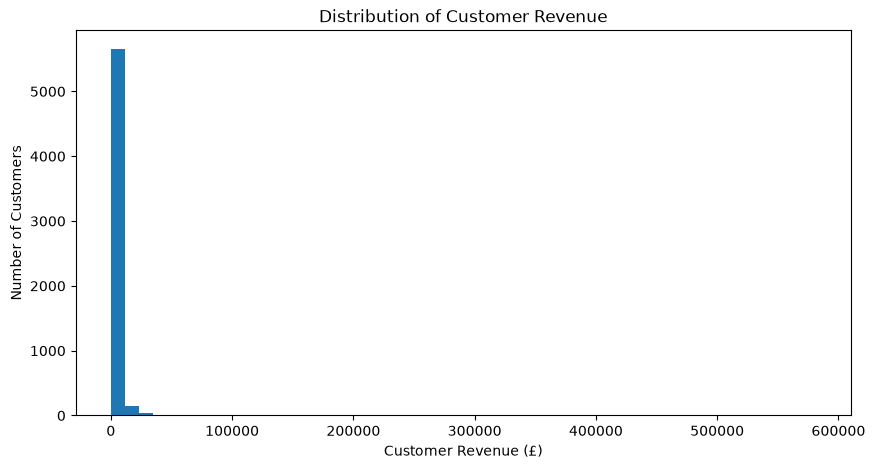

In [73]:
plt.figure(figsize=(10, 5))

plt.hist(
    customer_summary["total_revenue"],
    bins=50
)

plt.title("Distribution of Customer Revenue")
plt.xlabel("Customer Revenue (£)")
plt.ylabel("Number of Customers")

plt.show()

## 5.1 Customer Analysis Findings

- Customer revenue is strongly right-skewed. Mean customer revenue (£2,955.90) is substantially higher than the median (£867.74), indicating that a relatively small number of high-value customers pull the average upward.

- Customer value cannot be represented by revenue alone. The highest-revenue customer is not the most frequent purchaser, demonstrating that monetary value and purchase frequency capture different dimensions of customer behavior.

- Repeat customers represent 72.39% of identified customers but generate approximately 96.78% of identified-customer revenue. This suggests that repeat purchasing behavior is economically important and could justify further investigation of retention, loyalty, and repeat-purchase strategies.

- The top 10 customers generate approximately 16.04% of identified-customer revenue, indicating some customer revenue concentration, although additional concentration metrics would be required before concluding that the business is highly dependent on a small number of customers.

- Customer-level metrics can be distorted by transaction-level anomalies. Customer 16446 appears to be extremely valuable based on revenue and average order value, but most of this value originates from the previously identified extreme `PAPER CRAFT, LITTLE BIRDIE` transaction. Such anomalies should be investigated before customer segmentation or modeling.

In [74]:
print("EDA dataset rows:", len(transactions))
print("Merchandise rows:", len(product_transactions))
print("Identified customers:", customer_summary["customer_id"].nunique())
print("Total customer revenue:", customer_summary["total_revenue"].sum())
print("Repeat customer rate:", f"{repeat_customers / total_customers:.2%}")
print("Top 10 customer revenue share:", f"{top_10_customer_share:.2%}")

EDA dataset rows: 1007913
Merchandise rows: 1005647
Identified customers: 5878
Total customer revenue: 17374804.268
Repeat customer rate: 72.39%
Top 10 customer revenue share: 16.04%
